In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm # CDF norm dist
from datetime import datetime
import abc
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
sns.set_style('darkgrid')

In [2]:
TICKER = 'TSLA' # Tesla

# Options Pricing

This notebook explores key models and methodologies used in options pricing. Understanding and accurately estimating the fair value of options provides valuable insights for both risk management and strategy development in financial markets. Here, we dive into two foundational pricing models: Black-Scholes and the Binomial model, both of which have unique strengths and applications within the realm of derivatives pricing.

## 1. Overview

Options are financial derivatives that provide the right, but not the obligation, to buy or sell an underlying asset at a predetermined price, known as the strike price, on or before a specified expiration date. Options come in two main types: **calls**, which give the holder the right to buy, and **puts**, which give the holder the right to sell. The value of an option is composed of **intrinsic value** (the difference between the current asset price and the strike price) and **extrinsic value** (additional value attributed to time and volatility).

Options pricing is influenced by several key factors: **time to expiration** (the longer the time, the greater the potential for value changes), **volatility** of the underlying asset (higher volatility generally increases option prices), **interest rates** (affecting the cost of carrying options), and the **price of the underlying asset**. These factors, combined, impact an option's fair value and its behavior under changing market conditions, making options valuable tools for hedging and speculative strategies in financial markets.

In [3]:
def get_stock_vol(prices: pd.Series, trading_days:int=252):
    returns = prices / prices.shift(1)
    log_returns = np.log(returns)
    return log_returns.std() * (trading_days**0.5)

def get_option(symbol:str) -> tuple[pd.DataFrame, pd.DataFrame, datetime]:
    
    ticker = yf.Ticker(symbol)
    expiration_dates = ticker.options

    if len(expiration_dates) == 0:
        print(f'There are no listed options for {symbol}')
        return [], [], None

    options = ticker.option_chain(expiration_dates[0])
    return options.calls, options.puts, expiration_dates[0]

def get_period(date):
    date = datetime.strptime(date, '%Y-%m-%d')
    current_date = datetime.now()
    years_difference = (date - current_date).days / 365
    return years_difference

def get_option_chain(symbol):

    ticker = yf.Ticker(symbol)
    expiration_dates = ticker.options

    options_df = pd.DataFrame()

    for exp_dt in expiration_dates:
        option = ticker.option_chain(exp_dt)
        option = pd.DataFrame([*option.calls.values, *option.puts.values], columns=option.calls.columns)
        option['expiration_date'] = pd.to_datetime(exp_dt).date()
        option['days_to_expire'] = get_period(exp_dt)
        option['type'] = option['contractSymbol'].str[10].apply(lambda e: 'Call' if e == 'C' else 'Put')
        options_df = pd.concat([options_df, option])

    return options_df

def get_treasury_10():
    today = datetime.now()
    start_date = today.replace(year=today.year-10)
    data = yf.download('^TNX', start=start_date)
    return data['Close'].iloc[-1] / 100


In [4]:
closes = yf.download(TICKER)['Close']
options = get_option_chain(TICKER)
options.head(3)

[*********************100%***********************]  1 of 1 completed


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,expiration_date,days_to_expire,type
0,TSLA260401C00250000,2026-04-01 16:36:51+00:00,250.0,131.35,130.95,131.85,-5.75,-4.194019,433.0,2,3.164065,True,REGULAR,USD,2026-04-01,-0.00274,Call
1,TSLA260401C00265000,2026-03-30 18:37:26+00:00,265.0,90.87,115.40,117.75,0.00,0.000000,1.0,0,3.925781,True,REGULAR,USD,2026-04-01,-0.00274,Call
2,TSLA260401C00272500,2026-03-30 13:38:48+00:00,272.5,89.50,107.90,110.45,0.00,0.000000,1.0,0,3.800782,True,REGULAR,USD,2026-04-01,-0.00274,Call


## 1.1 Options Analysis

### 1.1.1 Implied Volatility

C:\Users\drewr\AppData\Local\Temp\ipykernel_11588\2987868547.py:13: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead



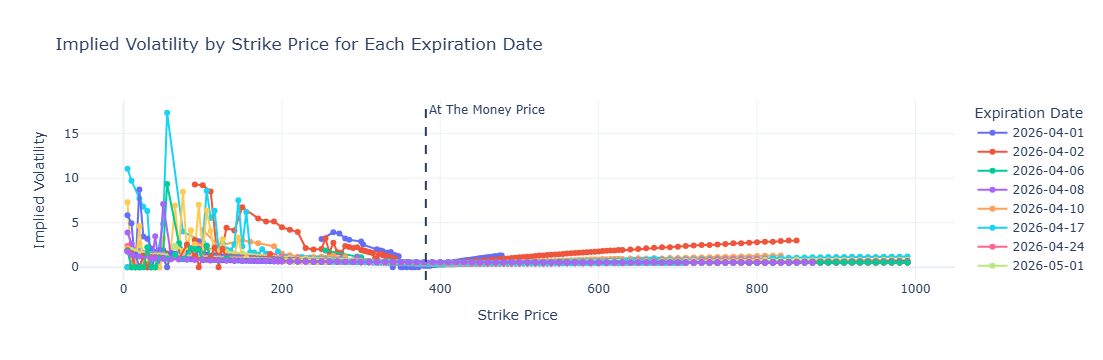

In [5]:
call_options = options[options['type'] == 'Call']
fig = go.Figure()

for expiration, group in call_options.groupby('expiration_date'):
    fig.add_trace(go.Scatter(
        x=group['strike'],
        y=group['impliedVolatility'],
        mode='markers+lines',
        name=str(expiration)
    ))

# Ensure we pass a scalar value for the stock price
atm_price = float(closes.iloc[-1])  # convert to scalar safely

fig.add_vline(
    x=atm_price,
    line_dash='dash',
    annotation_text="At The Money Price",
    annotation_position="top right",
)

fig.update_layout(
    title="Implied Volatility by Strike Price for Each Expiration Date",
    xaxis_title="Strike Price",
    yaxis_title="Implied Volatility",
    legend_title="Expiration Date",
    template="plotly_white"
)

fig.show()

## 2. The Greeks

The Greeks are key metrics that measure different risks in options trading. They can be used to manage exposure to various factors, ensuring that risks stay within acceptable levels. 

### 2.1. Delta (Δ)

Measures the rate of change of an option's price with respect to changes in the price of the underlying asset. In other words, it represents how much the price of the option is expected to change for a small change in the underlying asset's price.

In [6]:
def delta(d1:float, is_call:bool):
    signal = 1 if is_call else -1
    return signal*norm.cdf(signal*d1, 0.0, 1.0)

### 2.2 Gamma (Γ)

Measures the rate of change of Delta with respect to changes in the price of the underlying asset. It indicates how much Delta will change when the price of the underlying asset changes. Gamma is important for understanding the curvature of the option's price relative to changes in the underlying asset's price.

In [7]:
def gamma(d1, S, sigma, T):
        return norm.pdf(d1, 0.0, 1.0) / (S * sigma * np.sqrt(T))

### 2.3 Theta (Θ) or Time Decay

Measures the rate of change of the option's price with respect to time. Theta is negative for **call** and **put** options, meaning that as time passes, the option's value decreases.

In [8]:
def theta(d1, d2, S, sigma, T, r, K, is_call):
    signal = 1 if is_call else -1
    return (-S * norm.pdf(d1, 0.0, 1.0) * sigma / (2 * np.sqrt(T)) - signal * r * K * np.exp(-r * T) * norm.cdf(signal*d2, 0.0, 1.0))

### 2.4 Vega (V)

Measures the sensitivity of the option's price to changes in the volatility of the underlying asset. Vega is always positive for both **call** and **put** options, indicating that an increase in volatility increases the price of the option.

In [9]:
def vega(d1, S, T):
        return S * norm.pdf(d1, 0.0, 1.0) * np.sqrt(T)

### 2.5 Rho (ρ)

Measures the sensitivity of the option's price to changes in the risk-free interest rate. Rho is positive for **call** options and negative for **put** options. This means that for call options, as interest rates rise, the price of the option increases, and for put options, as interest rates rise, the price decreases.

In [10]:
def rho(d2, K, T, r, is_call):
        signal = 1 if is_call else -1
        return signal * K * T * np.exp(-r * T) * norm.cdf(signal*d2, 0.0, 1.0)

## Pricinng Models

In [11]:
class OptionPricingBaseModel:

    """
    Abstract base class for option pricing models, providing a structure for 
    calculating call and put option prices and their associated Greeks.

    Attributes:
    - S (float): Underlying asset price.
    - K (float): Strike price.
    - r (float): Risk-free interest rate (annualized).
    - sigma (float): Volatility of the underlying asset.
    - T (float): Time to expiration in years.
    - expiration_date (datetime, optional): The expiration date of the option (used if T is not provided).
    
    Methods:
    - get_call_price(): Abstract method to calculate call option price.
    - get_put_price(): Abstract method to calculate put option price.
    - get_call_greeks(): Calculates and returns the Greeks for a call option.
    - get_put_greeks(): Calculates and returns the Greeks for a put option.
    - get_call(call): Calculates the price and Greeks for a call option.
    - get_put(put): Calculates the price and Greeks for a put option.
    """

    def __init__(self, S:float, K:float, r:float, sigma:float, T=None, expiration_date=None):
        assert T is not None or expiration_date is not None, \
        'You must specify either the option expiration date or the time to expire (in years)'

        self.S = S # Underlying price
        self.K = K # Strike
        self.r = r # Risk-free rate
        self.sigma = sigma  # Volatility of the underlying asset
        self.T = T or get_period(expiration_date)
    
    def get_call(self):
        price = self.get_call_price()
        greeks = self.get_call_greeks()
        return pd.Series({f'price': price, **greeks}).add_prefix(self._model_prefix)
    
    def get_put(self):
        price = self.get_put_price()
        greeks = self.get_put_greeks()
        return pd.Series({f'price': price, **greeks}).add_prefix(self._model_prefix)

    @property 
    @abc.abstractmethod
    def _model_prefix(self) -> str:
        pass

    @abc.abstractmethod
    def get_call_price(self):
        pass

    @abc.abstractmethod
    def get_put_price(self):
        pass

    @abc.abstractmethod
    def _get_greeks(self, is_call) -> dict:        
        pass

    def get_call_greeks(self) -> dict:
        return self._get_greeks(is_call=True)

    def get_put_greeks(self) -> dict:
        return self._get_greeks(is_call=False)


# Black-Scholes

The Black-Scholes Model is a solution for pricing European-style options. This model assumes a constant volatility and a frictionless market, allowing us to calculate the theoretical price of options based on the underlying asset's current price, strike price, time to expiration, risk-free rate, and volatility. While the Black-Scholes Model is highly efficient and widely used in the industry, it does have some limitations, particularly in accounting for changes in volatility over time or the early exercise feature of American options.

**Assumptions**

- Constant Volatility
- No Dividends
- Log-Normal Distribution of Asset Prices
- European Option
- No Transaction Costs
- Risk-Free Rate is Constant

In [12]:
class BlackScholes(OptionPricingBaseModel):

    def __init__(self, S: float, K: float, r: float, sigma: float, T=None, expiration_date=None):
        assert T is not None or expiration_date is not None, \
            'You must specify either the option expiration date or the time to expire (in years)'
        
        super().__init__(S, K, r, sigma, T, expiration_date)

        self.S = float(S.iloc[0]) if hasattr(S, 'iloc') else float(S)
        self.K = float(K.iloc[0]) if hasattr(K, 'iloc') else float(K)
        self.r = float(r.iloc[0]) if hasattr(r, 'iloc') else float(r)
        self.sigma = float(sigma.iloc[0]) if hasattr(sigma, 'iloc') else float(sigma)

        # Compute time to expiration safely
        self.T = float(T if T is not None else self._get_safe_T(expiration_date))

    def _get_safe_T(self, expiration_date):
        from datetime import datetime
        T = get_period(expiration_date)
        # Cap T at minimum 1 day (so sqrt(T) never fails)
        return max(T, 1/365)

    @property
    def d1(self):
        return (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma ** 2) * self.T) / (self.sigma * np.sqrt(self.T))

    @property
    def d2(self):
        return self.d1 - self.sigma * np.sqrt(self.T)

    def get_call_price(self):
        return float(
            self.S * norm.cdf(self.d1, 0.0, 1.0)
            - self.K * np.exp(-self.r * self.T) * norm.cdf(self.d2, 0.0, 1.0)
        )
    
    def get_put_price(self):
        return float(
            self.K * np.exp(-self.r * self.T) * norm.cdf(-self.d2, 0.0, 1.0)
            - self.S * norm.cdf(-self.d1, 0.0, 1.0)
        )

    def _get_greeks(self, is_call):
        return {
            'delta': float(delta(self.d1, is_call)),
            'gamma': float(gamma(self.d1, self.S, self.sigma, self.T)),
            'theta': float(theta(self.d1, self.d2, self.S, self.sigma, self.T, self.r, self.K, is_call)),
            'vega': float(vega(self.d1, self.S, self.T)),
            'rho': float(rho(self.d1, self.K, self.T, self.r, is_call))
        }

    def get_call(self):
        price = self.get_call_price()
        greeks = self._get_greeks(is_call=True)
        return {
            'bsm_price': price,
            'bsm_delta': greeks['delta'],
            'bsm_gamma': greeks['gamma'],
            'bsm_theta': greeks['theta'],
            'bsm_vega': greeks['vega'],
            'bsm_rho': greeks['rho']
        }

    def get_put(self):
        price = self.get_put_price()
        greeks = self._get_greeks(is_call=False)
        return {
            'bsm_price': price,
            'bsm_delta': greeks['delta'],
            'bsm_gamma': greeks['gamma'],
            'bsm_theta': greeks['theta'],
            'bsm_vega': greeks['vega'],
            'bsm_rho': greeks['rho']
        }

    @property
    def _model_prefix(self):
        return 'bsm_'

In [13]:
calls, puts, date = get_option(TICKER)
closes = yf.download(TICKER)['Close']

r = get_treasury_10()
S = closes.iloc[-1]
sigma = get_stock_vol(closes)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [14]:
# Apply Black-Scholes and expand into columns
bsm_calls_df = calls.apply(
    lambda x: BlackScholes(
        S=S,
        K=x['strike'],
        r=r,
        sigma=sigma,
        expiration_date=date
    ).get_call(),
    axis=1,
    result_type='expand'
)

# Merge results back
calls = pd.concat([calls, bsm_calls_df], axis=1)

calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,bsm_price,bsm_delta,bsm_gamma,bsm_theta,bsm_vega,bsm_rho
0,TSLA260401C00250000,2026-04-01 16:36:51+00:00,250.0,131.35,130.95,131.85,-5.750000,-4.194019,433.0,2,2.921878,True,REGULAR,USD,131.839391,1.0,1.025765e-93,-10.761230,1.614197e-91,0.684851
1,TSLA260401C00265000,2026-03-30 18:37:26+00:00,265.0,90.87,115.40,117.75,0.000000,0.000000,1.0,0,3.892578,True,REGULAR,USD,116.841160,1.0,3.106430e-70,-11.406904,4.888440e-68,0.725942
2,TSLA260401C00272500,2026-03-30 13:38:48+00:00,272.5,89.50,107.90,110.45,0.000000,0.000000,1.0,0,3.773438,True,REGULAR,USD,109.342044,1.0,3.243648e-60,-11.729741,5.104374e-58,0.746487
3,TSLA260401C00280000,2026-04-01 15:22:04+00:00,280.0,101.57,100.80,102.50,7.940002,8.480191,1.0,1,3.205080,True,REGULAR,USD,101.842929,1.0,3.122798e-51,-12.052578,4.914198e-49,0.767033
4,TSLA260401C00285000,2026-03-19 13:51:59+00:00,285.0,99.78,95.40,97.50,0.000000,0.000000,NaN,27,3.048831,True,REGULAR,USD,96.843518,1.0,8.821772e-46,-12.267802,1.388240e-43,0.780730


In [15]:
bsm_puts_df = calls.apply(lambda x: BlackScholes(S=S, K=x['strike'], r=r, sigma=sigma, expiration_date=date).get_put(), axis=1)
puts = pd.concat([puts, bsm_puts_df], axis=1)
puts.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,0
0,TSLA260401P00250000,2026-03-30 19:58:43+00:00,250.0,0.01,0.0,0.01,0.0,0.0,1069.0,1111,2.437504,False,REGULAR,USD,"{'bsm_price': 1.4971030803228808e-94, 'bsm_del..."
1,TSLA260401P00252500,2026-03-30 19:58:40+00:00,252.5,0.01,0.0,0.01,0.0,0.0,1195.0,1178,2.375004,False,REGULAR,USD,"{'bsm_price': 6.080886302107404e-71, 'bsm_delt..."
2,TSLA260401P00255000,2026-03-30 19:51:31+00:00,255.0,0.01,0.0,0.01,0.0,0.0,234.0,215,2.312504,False,REGULAR,USD,"{'bsm_price': 7.431391751294933e-61, 'bsm_delt..."
3,TSLA260401P00257500,2026-03-30 19:54:15+00:00,257.5,0.01,0.0,0.01,0.0,0.0,9.0,10,2.312504,False,REGULAR,USD,"{'bsm_price': 8.444701835734576e-52, 'bsm_delt..."
4,TSLA260401P00260000,2026-03-31 13:35:08+00:00,260.0,0.04,0.0,0.01,0.0,0.0,1.0,91,2.250004,False,REGULAR,USD,"{'bsm_price': 2.678694141881978e-46, 'bsm_delt..."
